In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sqlite3

# Importando os dados para CSV

Para a etapa exploratória, optei por transformar o arquivo ```db``` em csv.

In [2]:
# Caminho completo do banco
db_path = r"C:\Users\Meu Computador\anaconda3\EBAC\Projetos\Em andamento\Barra_velha_weather\Data\weather.db"

# Conecta ao banco
conn = sqlite3.connect(db_path)

# Verifica tabelas existentes
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Se aparecer weather_data, exporta:
df = pd.read_sql_query("SELECT * FROM weather_data", conn)

df.to_csv("weather_data.csv", index=False)

conn.close()

In [3]:
df.head()

,id,date,year,month,day,avg_temp,max_temp,min_temp,humidity,precipitation
0,1,2025-01-01,2025,1,1,24.0,27.0,21.8,86.0,2.50
1,2,2025-01-02,2025,1,2,24.2,29.2,21.4,88.0,2.39
2,3,2025-01-03,2025,1,3,25.7,34.3,19.7,76.0,0.00
3,4,2025-01-04,2025,1,4,24.0,30.0,21.0,78.0,0.60
4,5,2025-01-05,2025,1,5,23.0,27.5,19.4,74.0,0.40


## Análise das colunas

### Exclusão
As colunas ```ID``` e ```date``` não fazem sentido para essa análise, visto que ID se refere a quantidade de linhas e date já está separada nas colunas dia, mês e ano.

### Criação
Acrescentarei a coluna ```amplitude```, que é o resultado da **max_temp** - **min_temp**. Essa variável ajudará a entender o comportamento climático.

In [4]:
# Criando uma cópia de segurança do dataset original
new_df = df.copy()

# Dropando as colunas id e date
new_df = new_df.drop(columns=['id', 'date'])

# Criando a coluna amplitude
new_df['amplitude'] = new_df['max_temp'] - new_df['min_temp']

In [36]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           365 non-null    int64  
 1   month          365 non-null    int64  
 2   day            365 non-null    int64  
 3   avg_temp       365 non-null    float64
 4   max_temp       365 non-null    float64
 5   min_temp       365 non-null    float64
 6   humidity       365 non-null    float64
 7   precipitation  365 non-null    float64
 8   amplitude      365 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 25.8 KB


In [37]:
# Não há valores nulos

new_df.isnull().sum()

year             0
month            0
day              0
avg_temp         0
max_temp         0
min_temp         0
humidity         0
precipitation    0
amplitude        0
dtype: int64

In [39]:
new_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,365.0,2025.000000,0.000000,2025.0,2025.0,2025.0,2025.0,2025.0
month,365.0,6.526027,3.452584,1.0,4.0,7.0,10.0,12.0
day,365.0,15.720548,8.808321,1.0,8.0,16.0,23.0,31.0
avg_temp,365.0,20.103014,3.877431,9.4,17.3,20.1,23.4,28.2
max_temp,365.0,23.839452,4.547150,10.6,20.4,23.7,27.3,35.5
min_temp,365.0,17.426027,3.861362,5.1,14.8,17.9,20.6,24.6
humidity,365.0,83.528767,7.119264,56.0,80.0,84.0,89.0,96.0
precipitation,365.0,3.908301,7.082573,0.0,0.1,1.1,4.7,65.9
amplitude,365.0,6.413425,2.414860,0.7,5.0,6.5,8.0,14.6


## Gráficos

Nesta etapa, analisei os dados usando gráficos para identificar padrões, possíveis *outliers* e etc.

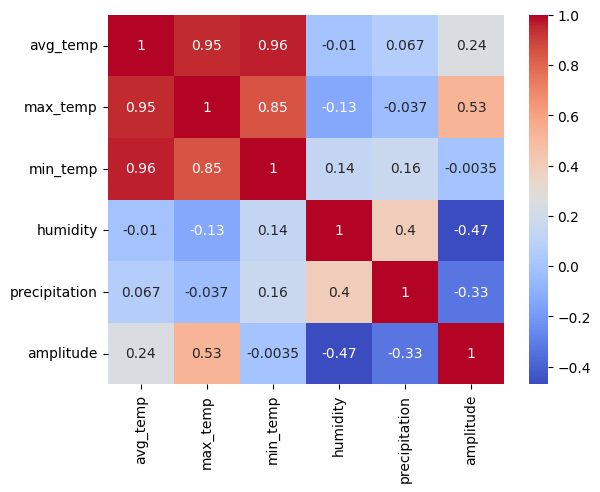

,avg_temp,max_temp,min_temp,humidity,precipitation,amplitude
avg_temp,1.000000,0.948297,0.964057,-0.010090,0.066967,0.244103
max_temp,0.948297,1.000000,0.847329,-0.134995,-0.037054,0.528107
min_temp,0.964057,0.847329,1.000000,0.135231,0.162294,-0.003491
humidity,-0.010090,-0.134995,0.135231,1.000000,0.395900,-0.470428
precipitation,0.066967,-0.037054,0.162294,0.395900,1.000000,-0.329280
amplitude,0.244103,0.528107,-0.003491,-0.470428,-0.329280,1.000000


In [8]:
corr = new_df[["avg_temp", "max_temp","min_temp","humidity","precipitation","amplitude"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

corr

# Análise de Correlação – Dados Climáticos

## Visão Geral

Foi realizada uma análise de correlação entre as principais variáveis climáticas:

- Temperatura média (`avg_temp`)
- Temperatura máxima (`max_temp`)
- Temperatura mínima (`min_temp`)
- Umidade (`humidity`)
- Precipitação (`precipitation`)
- Amplitude térmica (`amplitude`)

Os coeficientes variam de **-1 a +1**, onde:
- **+1** → correlação positiva forte
- **-1** → correlação negativa forte
- **0** → ausência de correlação linear

---

## Forte Correlação entre as Temperaturas

- A temperatura média é fortemente influenciada pelas temperaturas mínima e máxima.
- Existe alta **colinearidade** entre variáveis térmicas.
- O comportamento é estatisticamente consistente e esperado do ponto de vista climático, visto que a média depende da mínima e da máxima.

---

## Amplitude Térmica e Temperatura Máxima

- Dias mais quentes tendem a apresentar maior variação térmica.
- Isso pode indicar maior incidência solar e céu limpo.
- Sugere influência da radiação solar na variabilidade diária da temperatura.

---

## Amplitude e Umidade

- Existe uma correlação negativa moderada: quanto maior a umidade, menor a amplitude térmica.
- Quanto mais seco o dia, maior a variação entre máxima e mínima.
- **Alta** umidade retém calor durante a noite.
- **Baixa** umidade favorece maior resfriamento noturno.

---

## Precipitação e Umidade

- Correlação positiva moderada.
- Dias mais úmidos tendem a apresentar maior volume de chuva.
- Relação esperada do ponto de vista meteorológico.

---

## Precipitação e Amplitude

- Dias chuvosos tendem a apresentar menor variação térmica.
- A presença de nuvens reduz a temperatura máxima.
- A cobertura de nuvens também reduz a perda de calor noturna.

---

## Temperatura Média e Umidade

- Praticamente não há correlação linear.
- A umidade não impacta significativamente o nível médio da temperatura.
- Seu impacto ocorre principalmente na estabilidade térmica (amplitude).

---

# Conclusões

- Variáveis de temperatura apresentam alta colinearidade.
- A umidade é um fator importante para explicar a estabilidade térmica.
- Dias secos apresentam maior amplitude térmica.
- Dias úmidos e chuvosos apresentam menor variação térmica.
- Os padrões identificados são coerentes com o comportamento climático esperado.

---

In [9]:
def graf_hist(var, titulo):
    plt.figure()
    sns.histplot(new_df[var], bins=20)
    plt.title(titulo)
    plt.xlabel(var)
    plt.ylabel("Frequência")
    plt.show()

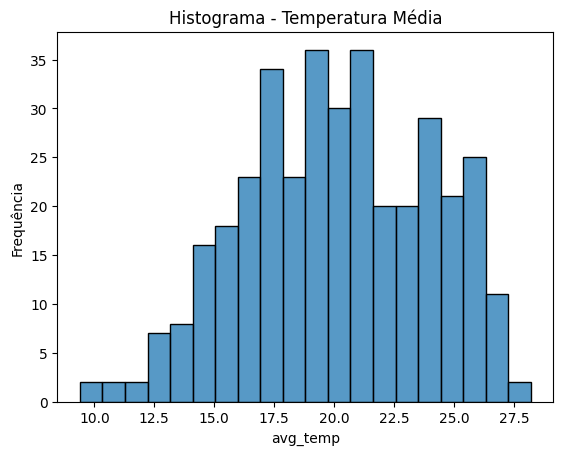

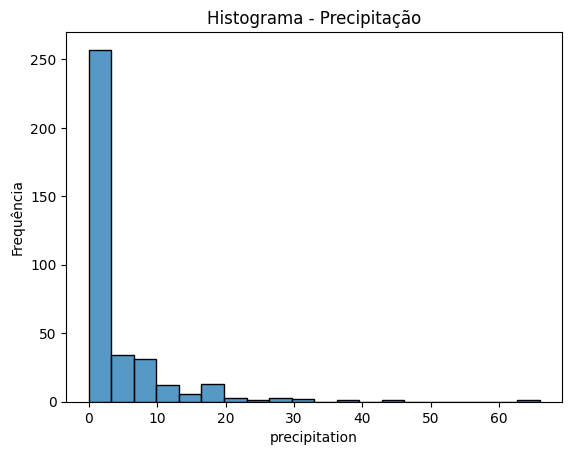

In [10]:
graf_hist("avg_temp", "Histograma - Temperatura Média")
graf_hist("precipitation", "Histograma - Precipitação")

In [30]:
def graf_bar_month(y, titulo):
    fig, ax = plt.subplots()
    ax.bar(new_df['month'], new_df[y], width=0.9, linewidth=0.7)
    plt.title(titulo, fontsize=12, pad=10)
    plt.show()

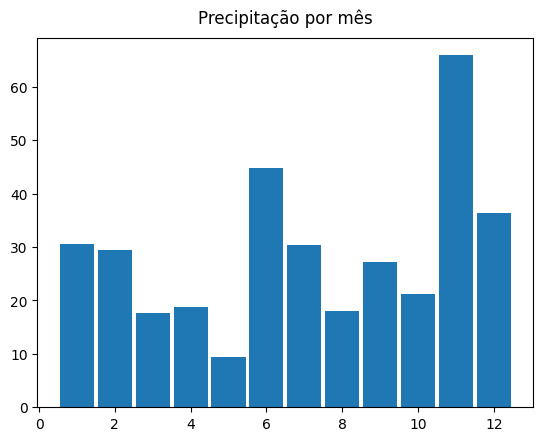

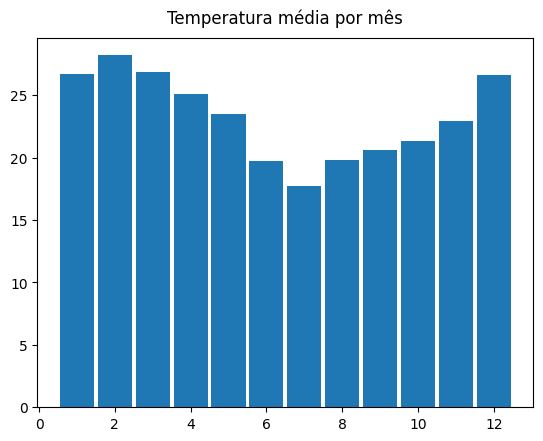

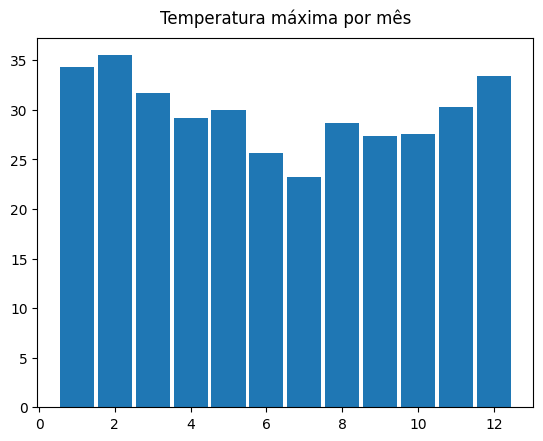

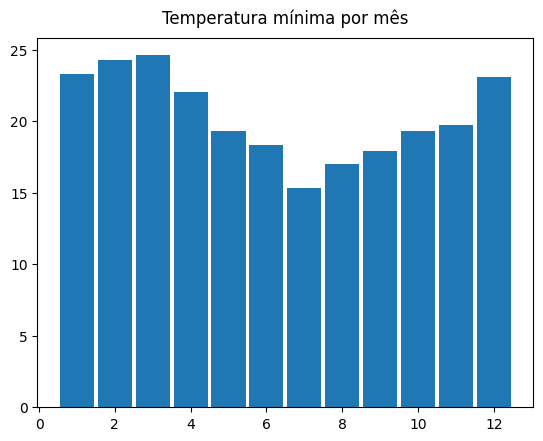

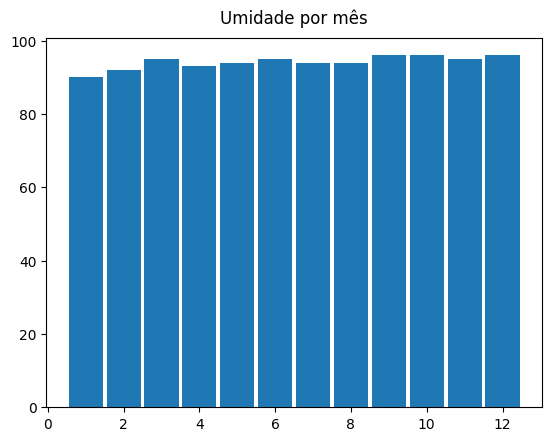

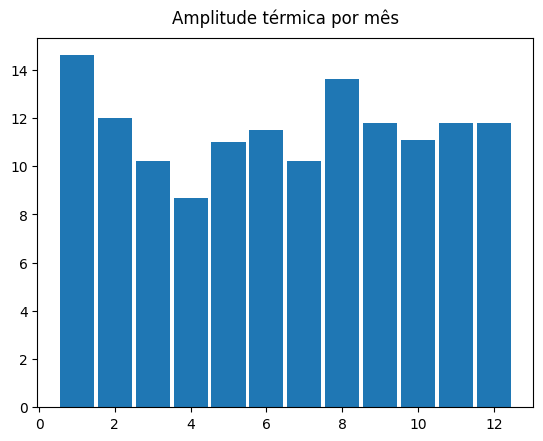

In [33]:
graf_bar_month('precipitation', 'Precipitação por mês')
graf_bar_month('avg_temp', 'Temperatura média por mês')
graf_bar_month('max_temp', 'Temperatura máxima por mês')
graf_bar_month('min_temp', 'Temperatura mínima por mês')
graf_bar_month('humidity', 'Umidade por mês')
graf_bar_month('amplitude', 'Amplitude térmica por mês')